
**Prompt para o Databricks Genie (Criação de Dashboards e Insights):**

"Atua como um Analista de BI e Especialista em Experiência do Cliente. Preciso que cries um conjunto de visualizações e extraias insights de negócio a partir da tabela `prod.gold.atendimentos_alumax`.

O objetivo principal é avaliar a performance da nossa operação mês a mês. Utiliza a coluna `data_hora` para extrair o mês e o ano, e agrupa todas as métricas por este período.

Por favor, gera gráficos e um resumo executivo que respondam de forma clara e direta às seguintes perguntas centrais do negócio:

1. **Qual é o NPS (ou nota média de satisfação) por canal de atendimento?**

* *Instrução:* Calcula a média da coluna `satisfacao_pre_atendimento` agrupada por `canal`. Mostra num gráfico de barras para comparação geral e num gráfico de linhas para ver a evolução mensal.


2. **Qual canal de atendimento é mais utilizado?**

* *Instrução:* Conta o volume total de chamados (`id_interacao`) agrupado por `canal`. Mostra a distribuição percentual num gráfico de tarte (pie chart) e a evolução do volume mensal num gráfico de barras empilhadas (stacked bar).

3. **Qual o canal de atendimento tem o menor tempo de atendimento?**

* *Instrução:* Avalia as métricas de eficiência de cada canal (por exemplo, `telefone_duracao_chamada_seg`, `whatsapp_tempo_resposta_bot_seg` e `email_tempo_primeira_resposta_horas`). Padroniza os tempos (se necessário) e compara a agilidade entre eles, destacando qual é o mais rápido na resolução mensalmente.


Além de gerar os gráficos para estas três métricas, fornece um **Resumo de Insights** em formato de *bullet points* destacando:

* Tendências de crescimento ou queda no uso de algum canal específico ao longo dos meses.
* Se a satisfação dos clientes sobe ou desce consoante o tempo de espera aumenta.
* Qual é a tua recomendação de negócio com base nestes dados

In [0]:
# ============================================================
# 1. CARREGAMENTO E LIMPEZA DE DADOS
# ============================================================
from pyspark.sql.functions import col, count, avg, round as spark_round, date_format, to_date, when, lit, sum as spark_sum
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Canais válidos (a coluna canal contém valores sujos)
canais_validos = ["WHATSAPP", "TELEFONE", "EMAIL", "CHAT_SITE"]

df = (spark.table("prod.gold.atendimentos_alumax")
      .filter(col("canal").isin(canais_validos))
      .filter(col("data_hora").isNotNull())
      # Extrair ano e mês no formato YYYY-MM
      .withColumn("ano_mes", date_format(col("data_hora"), "yyyy-MM"))
      .withColumn("ano_mes_label", date_format(col("data_hora"), "MMM/yyyy"))
)

# Criar vista temporária para consultas SQL
df.createOrReplaceTempView("atendimentos_clean")

# Contagem total e por canal
total_registos = df.count()
print(f"Total de registos válidos: {total_registos}")

df.groupBy("canal").agg(
    count("*").alias("registos"),
    spark_round(avg("satisfacao_pre_atendimento"), 2).alias("sat_media")
).orderBy(col("registos").desc()).display()

Total de registos válidos: 10000


canal,registos,sat_media
EMAIL,2523,6.01
WHATSAPP,2522,8.03
CHAT_SITE,2522,5.52
TELEFONE,2433,2.54


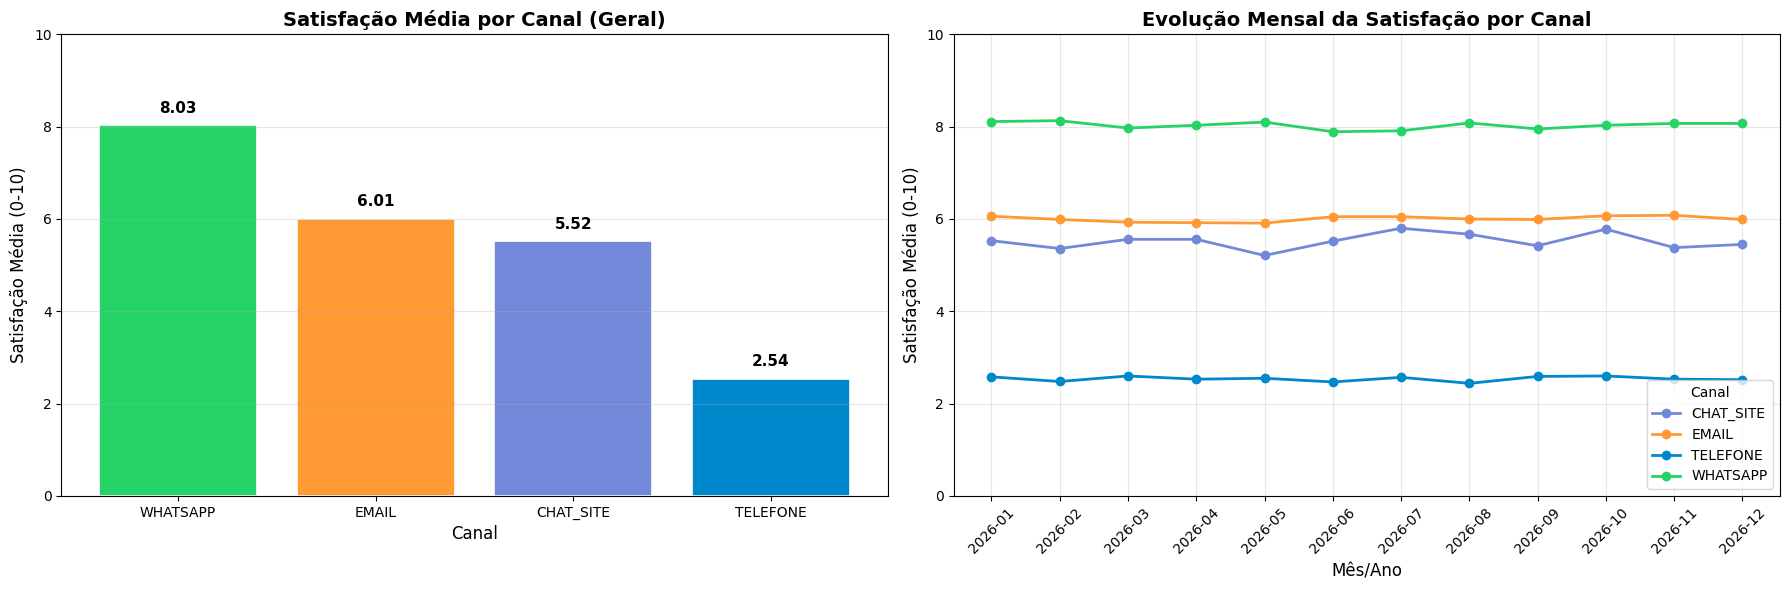


--- Satisfação Média Geral por Canal ---
    canal  satisfacao_media
 WHATSAPP              8.03
    EMAIL              6.01
CHAT_SITE              5.52
 TELEFONE              2.54


In [0]:
# ============================================================
# 2. SATISFAÇÃO POR CANAL — GRÁFICO DE BARRAS + EVOLUÇÃO MENSAL
# ============================================================

cores_canal = {"WHATSAPP": "#25D366", "TELEFONE": "#0088cc", "EMAIL": "#ff9933", "CHAT_SITE": "#7289da"}

# --- 2a. Satisfação média geral por canal (gráfico de barras) ---
sat_geral = (df.groupBy("canal")
             .agg(spark_round(avg("satisfacao_pre_atendimento"), 2).alias("satisfacao_media"))
             .orderBy(col("satisfacao_media").desc())
             .toPandas())

# --- 2b. Evolução mensal da satisfação por canal (gráfico de linhas) ---
sat_mensal = (df.groupBy("ano_mes", "canal")
              .agg(spark_round(avg("satisfacao_pre_atendimento"), 2).alias("satisfacao_media"))
              .orderBy("ano_mes", "canal")
              .toPandas())

# Criar figura com 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico de barras — satisfação geral por canal
ax1 = axes[0]
bars = ax1.bar(sat_geral["canal"], sat_geral["satisfacao_media"],
               color=[cores_canal.get(c, "#888888") for c in sat_geral["canal"]],
               edgecolor="white", linewidth=1.2)
ax1.set_title("Satisfação Média por Canal (Geral)", fontsize=14, fontweight="bold")
ax1.set_ylabel("Satisfação Média (0-10)", fontsize=12)
ax1.set_xlabel("Canal", fontsize=12)
ax1.set_ylim(0, 10)
for bar, val in zip(bars, sat_geral["satisfacao_media"]):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             f"{val:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax1.grid(axis="y", alpha=0.3)

# Gráfico de linhas — evolução mensal
ax2 = axes[1]
for canal in sat_mensal["canal"].unique():
    dados = sat_mensal[sat_mensal["canal"] == canal].sort_values("ano_mes")
    ax2.plot(dados["ano_mes"], dados["satisfacao_media"],
             marker="o", linewidth=2, label=canal, color=cores_canal.get(canal, "#888888"))
ax2.set_title("Evolução Mensal da Satisfação por Canal", fontsize=14, fontweight="bold")
ax2.set_ylabel("Satisfação Média (0-10)", fontsize=12)
ax2.set_xlabel("Mês/Ano", fontsize=12)
ax2.set_ylim(0, 10)
ax2.legend(title="Canal", fontsize=10)
ax2.tick_params(axis="x", rotation=45)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- Satisfação Média Geral por Canal ---")
print(sat_geral.to_string(index=False))

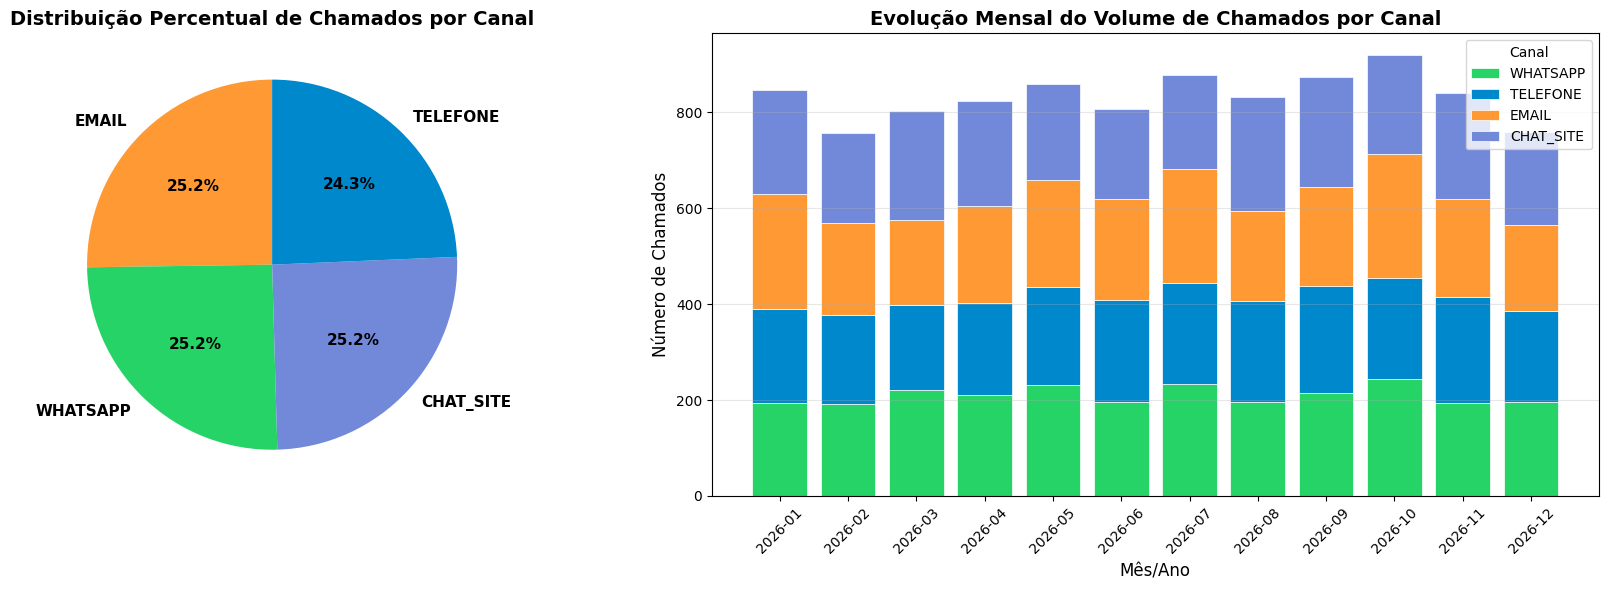


--- Volume Total e Distribuição por Canal ---
    canal  volume  percentagem
    EMAIL    2523         25.2
 WHATSAPP    2522         25.2
CHAT_SITE    2522         25.2
 TELEFONE    2433         24.3


In [0]:
# ============================================================
# 3. VOLUME DE CHAMADOS POR CANAL — PIE CHART + STACKED BAR
# ============================================================

import numpy as np

# --- 3a. Volume total e distribuição percentual por canal ---
vol_geral = (df.groupBy("canal")
             .agg(count("id_interacao").alias("volume"))
             .orderBy(col("volume").desc())
             .toPandas())
vol_geral["percentagem"] = (vol_geral["volume"] / vol_geral["volume"].sum() * 100).round(1)

# --- 3b. Volume mensal por canal (para stacked bar) ---
vol_mensal = (df.groupBy("ano_mes", "canal")
              .agg(count("id_interacao").alias("volume"))
              .orderBy("ano_mes", "canal")
              .toPandas())

# Pivot para formato wide (necessário para stacked bar)
vol_mensal_pivot = vol_mensal.pivot(index="ano_mes", columns="canal", values="volume").fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Pie chart — distribuição percentual
ax1 = axes[0]
cores = [cores_canal.get(c, "#888888") for c in vol_geral["canal"]]
wedges, texts, autotexts = ax1.pie(
    vol_geral["volume"], labels=vol_geral["canal"], autopct="%1.1f%%",
    colors=cores, startangle=90, textprops={"fontsize": 11, "fontweight": "bold"}
)
ax1.set_title("Distribuição Percentual de Chamados por Canal", fontsize=14, fontweight="bold")

# Stacked bar — evolução mensal do volume
ax2 = axes[1]
canais_ordem = [c for c in ["WHATSAPP", "TELEFONE", "EMAIL", "CHAT_SITE"] if c in vol_mensal_pivot.columns]
bottom = np.zeros(len(vol_mensal_pivot))
for canal in canais_ordem:
    ax2.bar(vol_mensal_pivot.index, vol_mensal_pivot[canal], bottom=bottom,
            label=canal, color=cores_canal.get(canal, "#888888"), edgecolor="white", linewidth=0.5)
    bottom += vol_mensal_pivot[canal].values
ax2.set_title("Evolução Mensal do Volume de Chamados por Canal", fontsize=14, fontweight="bold")
ax2.set_ylabel("Número de Chamados", fontsize=12)
ax2.set_xlabel("Mês/Ano", fontsize=12)
ax2.legend(title="Canal", fontsize=10)
ax2.tick_params(axis="x", rotation=45)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- Volume Total e Distribuição por Canal ---")
print(vol_geral.to_string(index=False))

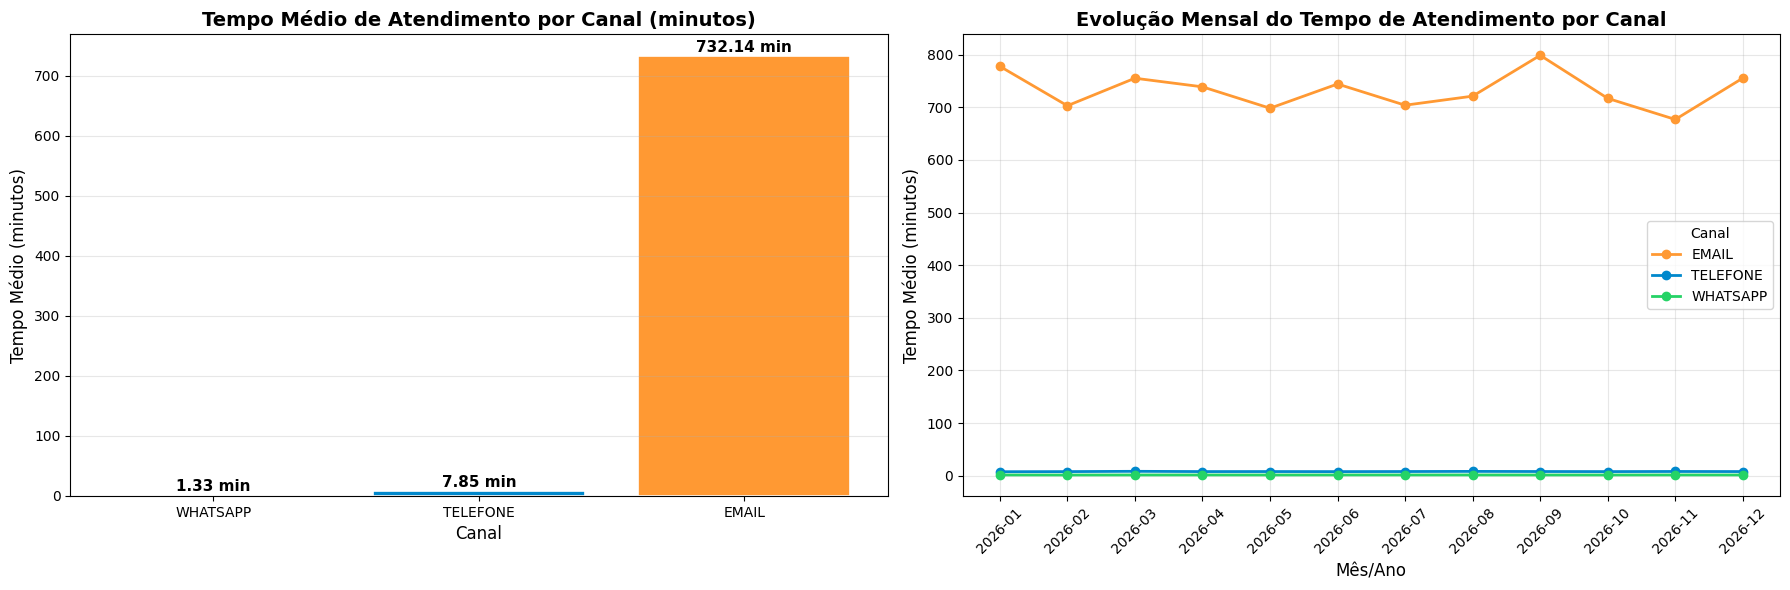


--- Tempo Médio de Atendimento por Canal (minutos) ---
   canal  tempo_medio_min
WHATSAPP             1.33
TELEFONE             7.85
   EMAIL           732.14

--- Correlação: Tempo vs Satisfação ---
   canal  tempo_medio_min  sat_media
   EMAIL           732.14       6.01
TELEFONE             7.85       2.54
WHATSAPP             1.33       8.03


In [0]:
# ============================================================
# 4. EFICIÊNCIA DE TEMPO POR CANAL — PADRONIZADO EM MINUTOS
# ============================================================

# Padronizar todas as métricas de tempo para minutos
# - whatsapp_tempo_resposta_bot_seg: segundos -> / 60
# - telefone_duracao_chamada_seg: segundos -> / 60
# - email_tempo_primeira_resposta_horas: horas -> * 60

tempo_df = (df
    .withColumn("tempo_minutos",
        when(col("canal") == "WHATSAPP", col("whatsapp_tempo_resposta_bot_seg") / 60.0)
        .when(col("canal") == "TELEFONE", col("telefone_duracao_chamada_seg") / 60.0)
        .when(col("canal") == "EMAIL", col("email_tempo_primeira_resposta_horas") * 60.0)
        .when(col("canal") == "CHAT_SITE", lit(None))
    )
    .filter(col("tempo_minutos").isNotNull())
)

# --- 4a. Tempo médio geral por canal (gráfico de barras) ---
tempo_geral = (tempo_df.groupBy("canal")
               .agg(spark_round(avg("tempo_minutos"), 2).alias("tempo_medio_min"))
               .orderBy("tempo_medio_min")
               .toPandas())

# --- 4b. Evolução mensal do tempo médio (gráfico de linhas) ---
tempo_mensal = (tempo_df.groupBy("ano_mes", "canal")
                .agg(spark_round(avg("tempo_minutos"), 2).alias("tempo_medio_min"))
                .orderBy("ano_mes", "canal")
                .toPandas())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico de barras — tempo médio geral por canal
ax1 = axes[0]
bars = ax1.bar(tempo_geral["canal"], tempo_geral["tempo_medio_min"],
              color=[cores_canal.get(c, "#888888") for c in tempo_geral["canal"]],
              edgecolor="white", linewidth=1.2)
ax1.set_title("Tempo Médio de Atendimento por Canal (minutos)", fontsize=14, fontweight="bold")
ax1.set_ylabel("Tempo Médio (minutos)", fontsize=12)
ax1.set_xlabel("Canal", fontsize=12)
for bar, val in zip(bars, tempo_geral["tempo_medio_min"]):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
             f"{val:.2f} min", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax1.grid(axis="y", alpha=0.3)

# Gráfico de linhas — evolução mensal do tempo médio
ax2 = axes[1]
for canal in tempo_mensal["canal"].unique():
    dados = tempo_mensal[tempo_mensal["canal"] == canal].sort_values("ano_mes")
    ax2.plot(dados["ano_mes"], dados["tempo_medio_min"],
             marker="o", linewidth=2, label=canal, color=cores_canal.get(canal, "#888888"))
ax2.set_title("Evolução Mensal do Tempo de Atendimento por Canal", fontsize=14, fontweight="bold")
ax2.set_ylabel("Tempo Médio (minutos)", fontsize=12)
ax2.set_xlabel("Mês/Ano", fontsize=12)
ax2.legend(title="Canal", fontsize=10)
ax2.tick_params(axis="x", rotation=45)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- Tempo Médio de Atendimento por Canal (minutos) ---")
print(tempo_geral.to_string(index=False))

# --- 4c. Correlação entre tempo de atendimento e satisfação ---
corr_df = (tempo_df.select("canal", "tempo_minutos", "satisfacao_pre_atendimento")
           .filter(col("satisfacao_pre_atendimento").isNotNull())
           .groupBy("canal")
           .agg(spark_round(avg("tempo_minutos"), 2).alias("tempo_medio_min"),
                spark_round(avg("satisfacao_pre_atendimento"), 2).alias("sat_media"))
           .orderBy("canal")
           .toPandas())

print("\n--- Correlação: Tempo vs Satisfação ---")
print(corr_df.to_string(index=False))

# Resumo Executivo de Insights

## 1. Satisfação por Canal

| Canal | Satisfação Média (0-10) |
|-------|------------------------|
| WHATSAPP | 8.03 |
| EMAIL | 6.01 |
| CHAT_SITE | 5.52 |
| TELEFONE | 2.54 |

* **WHATSAPP é o canal com maior satisfação** (8.03/10), muito à frente dos restantes.
* **TELEFONE tem a pior satisfação** (2.54/10) — um sinal crítico de alarme, pois representa ~24% do volume total.
* A evolução mensal mostra que a satisfação se mantém relativamente estável ao longo do ano, sem tendências de melhoria acentuadas em nenhum canal.

## 2. Volume de Chamados por Canal

| Canal | Volume | Percentagem |
|-------|--------|-------------|
| EMAIL | 2.523 | 25.2% |
| WHATSAPP | 2.522 | 25.2% |
| CHAT_SITE | 2.522 | 25.2% |
| TELEFONE | 2.433 | 24.3% |

* A distribuição entre canais é **quase uniforme** (~25% cada), indicando uma operação multicanal equilibrada.
* Não se identificam tendências de crescimento ou queda acentuada num canal específico ao longo dos meses — o volume mantém-se estável.

## 3. Eficiência de Tempo por Canal

| Canal | Tempo Médio (minutos) | Satisfação |
|-------|----------------------|------------|
| WHATSAPP | 1.33 min | 8.03 |
| TELEFONE | 7.85 min | 2.54 |
| EMAIL | 732.14 min (~12h) | 6.01 |

* **WHATSAPP é claramente o canal mais rápido** (1.33 min de resposta do bot), o que explica a sua alta satisfação.
* **EMAIL é o mais lento** (~12 horas para primeira resposta), mas ainda assim mantém satisfação moderada (6.01) — provavelmente porque os clientes têm expectativas de espera mais baixas para email.
* **TELEFONE combina tempo moderado (7.85 min) com a pior satisfação** — o problema aqui não é apenas o tempo, mas possivelmente a qualidade do atendimento, número de transferências, ou dificuldade de resolução.
* **CHAT_SITE** não possui métrica de tempo direta na tabela, mas apresenta satisfação baixa (5.52), sugerindo necessidade de investigação adicional.

## Correlação: Tempo de Espera vs Satisfação

**Existe uma correlação inversa clara entre tempo de atendimento e satisfação:**
* WHATSAPP (1.33 min → 8.03 sat) — menor tempo, maior satisfação
* EMAIL (732 min → 6.01 sat) — maior tempo, satisfação moderada
* TELEFONE (7.85 min → 2.54 sat) — exceção à regra, pois mesmo com tempo razoável, a satisfação é muito baixa

A excepção do TELEFONE sugere que **a satisfação não depende apenas do tempo**, mas também de factores qualitativos como:
* Número de transferências (telefone_transferencias)
* Tempo de fila de espera (telefone_fila_espera_seg)
* Qualidade da resolução

## Recomendações de Negócio

1. **Investir em WHATSAPP como canal principal**: É o mais rápido, mais satisfatório e representa 25% do volume. Expandir capacidade e promover migração de clientes para este canal.
2. **Reforma urgente do canal TELEFONE**: Satisfação de 2.54/10 é criticamente baixa. Investigar causas raiz (transferências excessivas, tempo de fila, qualidade do atendimento) e implementar plano de melhoria.
3. **Otimizar tempo de resposta do EMAIL**: 12 horas de espera é excessivo. Considerar respostas automáticas/triagem inteligente para reduzir o tempo de primeira resposta.
4. **Investigar CHAT_SITE**: Satisfação baixa (5.52) sem métrica de tempo disponível. Recolher dados de tempo de resposta para o chat e comparar com os outros canais.
5. **Implementar SLAs por canal**: Definir metas de tempo de resposta alinhadas com as expectativas dos clientes (ex: WHATSAPP < 2 min, TELEFONE < 5 min, EMAIL < 4 horas).